# Occupancy Grid VAE for Synthetic Peptides
Minimal implementation using 3D CNN for voxel-based representation

In [10]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import os
import glob
from torch.utils.data import Dataset, DataLoader

In [2]:
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

In [ ]:
def points_to_voxels(points, grid_size=32):
    """Convert point cloud to occupancy grid"""
    voxel_grid = np.zeros((grid_size, grid_size, grid_size))
    
    # Normalize points to [0, 1] then to grid indices
    points_norm = (points + 1) / 2  # from [-1,1] to [0,1]
    indices = (points_norm * (grid_size - 1)).astype(int)
    indices = np.clip(indices, 0, grid_size - 1)
    
    # Mark occupied voxels
    voxel_grid[indices[:, 0], indices[:, 1], indices[:, 2]] = 1
    return voxel_grid

class VoxelDataset(Dataset):
    def __init__(self, data_path='./data/synthetic_peptides', grid_size=32, num_files=None):
        self.files = []
        self.file_types = {}  # Track which subdirectory each file comes from
        subdirs = [[d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))][3]]
        
        print(f"Available peptide types: {[d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]}")
        print(f"Using peptide type: {subdirs}")
        
        for subdir in subdirs:
            pattern = os.path.join(data_path, subdir, '*.gro')
            subdir_files = glob.glob(pattern)
            self.files.extend(subdir_files)
            # Track file types
            for file in subdir_files:
                self.file_types[file] = subdir
            print(f"  - {subdir}: {len(subdir_files)} files")
        
        if num_files:
            self.files = self.files[:num_files]
        
        self.grid_size = grid_size
        print(f"Total loaded: {len(self.files)} files, grid size: {grid_size}^3")
    
    def get_file_type(self, idx):
        """Get the peptide type for a specific file index"""
        return self.file_types[self.files[idx]]
    
    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, idx):
        try:
            with open(self.files[idx], 'r') as f:
                lines = f.readlines()
            
            # Extract coordinates
            points = [[float(line.split()[i]) for i in [-3,-2,-1]] 
                     for line in lines[2:-1] if len(line.split()) >= 6]
            points = np.array(points)
            
            # Normalize to [-1,1]
            centroid = np.mean(points, axis=0)
            points = points - centroid
            max_dist = np.max(np.sqrt(np.sum(points**2, axis=1)))
            if max_dist > 0:
                points = points / max_dist
            
            # Convert to voxel grid
            voxel_grid = points_to_voxels(points, self.grid_size)
            return torch.tensor(voxel_grid, dtype=torch.float32).unsqueeze(0)  # [1, H, W, D]
            
        except:
            # Return empty grid on error
            return torch.zeros(1, self.grid_size, self.grid_size, self.grid_size)

# Test dataset
dataset = VoxelDataset(num_files=1, grid_size=16)
print(f"Sample voxel grid shape: {dataset[0].shape}")
print(f"Occupancy ratio: {dataset[0].sum().item() / dataset[0].numel():.4f}")

Available peptide types: ['micelles', 'random_aggregates', 'nanofibers', 'nanotubes']
Using peptide type: ['nanofibers']
  - nanofibers: 200 files
Total loaded: 1 files, grid size: 16^3
Sample voxel grid shape: torch.Size([1, 16, 16, 16])
Occupancy ratio: 0.0522


In [4]:
class OccupancyGridVAE(nn.Module):
    def __init__(self, latent_dim=64, grid_size=32):
        super().__init__()
        self.grid_size = grid_size
        
        # Encoder: 3D CNN
        self.encoder = nn.Sequential(
            nn.Conv3d(1, 16, 4, 2, 1),  # grid_size -> grid_size/2
            nn.ReLU(),
            nn.Conv3d(16, 32, 4, 2, 1), # grid_size/2 -> grid_size/4
            nn.ReLU(),
            nn.Conv3d(32, 64, 4, 2, 1), # grid_size/4 -> grid_size/8
            nn.ReLU(),
        )
        
        # Calculate final spatial size after convolutions
        final_size = grid_size // 8
        self.final_spatial = final_size
        
        # Latent space
        self.fc_mu = nn.Linear(64 * final_size**3, latent_dim)
        self.fc_var = nn.Linear(64 * final_size**3, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 64 * final_size**3)
        
        # Decoder: 3D Transposed CNN
        self.decoder = nn.Sequential(
            nn.ConvTranspose3d(64, 32, 4, 2, 1), # final_size -> final_size*2
            nn.ReLU(),
            nn.ConvTranspose3d(32, 16, 4, 2, 1), # final_size*2 -> final_size*4
            nn.ReLU(),
            nn.ConvTranspose3d(16, 1, 4, 2, 1),  # final_size*4 -> grid_size
            nn.Sigmoid()  # Occupancy probabilities
        )
    
    def encode(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        log_var = self.fc_var(x)
        return mu, log_var
    
    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        x = self.fc_decode(z)
        x = x.view(x.size(0), 64, self.final_spatial, self.final_spatial, self.final_spatial)
        x = self.decoder(x)
        return x
    
    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        recon = self.decode(z)
        return recon, mu, log_var

# Create model
model = OccupancyGridVAE(latent_dim=64, grid_size=16)  # Match dataset grid_size
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Expected input shape: [batch, 1, 16, 16, 16]")
print(f"Final spatial size: {model.final_spatial}")

Model parameters: 428,833
Expected input shape: [batch, 1, 16, 16, 16]
Final spatial size: 2


Using focal loss for reconstruction
Epoch 0: Loss = 7.59
Epoch 5: Loss = 1.07
Epoch 10: Loss = 5.28
Epoch 15: Loss = 7.43
Epoch 20: Loss = 4.39
Epoch 25: Loss = 0.94
Epoch 30: Loss = 3.92
Epoch 35: Loss = 5.04
Epoch 40: Loss = 9.59
Epoch 45: Loss = 8.36
Epoch 50: Loss = 5.02
Epoch 55: Loss = 2.36
Epoch 60: Loss = 1.03
Epoch 65: Loss = 4.96
Epoch 70: Loss = 0.95
Epoch 75: Loss = 1.19
Epoch 80: Loss = 1.20
Epoch 85: Loss = 1.05
Epoch 90: Loss = 0.86
Epoch 95: Loss = 0.66
Training complete!


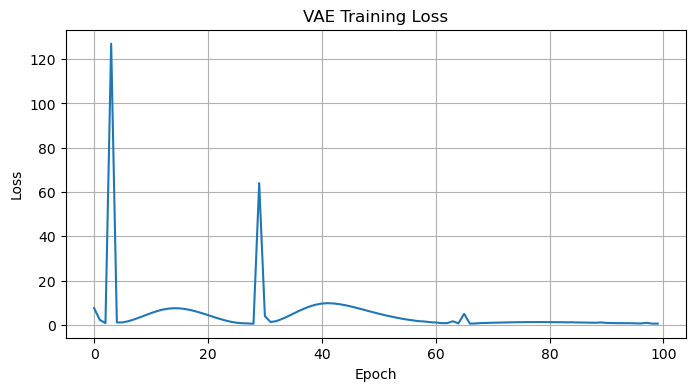

In [ ]:
def focal_loss(pred, target, alpha=0.25, gamma=2.0):
    """Focal loss for handling class imbalance in sparse voxel grids"""
    bce = nn.functional.binary_cross_entropy(pred, target, reduction='none')
    pt = torch.exp(-bce)
    focal = alpha * (1-pt)**gamma * bce
    return focal.sum()  # Sum for consistency with BCE reduction='sum'

def vae_loss(recon_x, x, mu, log_var, loss_type='bce', alpha=0.25, gamma=2.0):
    """VAE loss: reconstruction + KL divergence with choice of loss function"""
    
    # Reconstruction loss
    if loss_type == 'bce':
        recon_loss = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    elif loss_type == 'focal':
        recon_loss = focal_loss(recon_x, x, alpha=alpha, gamma=gamma)
    else:
        raise ValueError("loss_type must be 'bce' or 'focal'")
    
    # KL divergence
    KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    
    return recon_loss + 0.1 * KLD  # Weight KL term less

# Training setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

# Choose loss type: 'bce' or 'focal'
LOSS_TYPE = 'focal'  # Change to 'bce' for standard binary cross-entropy
print(f"Using {LOSS_TYPE} loss for reconstruction")

# Show training data composition
print(f"\n=== TRAINING DATA ===")
print(f"Training on peptide type: {list(dataset.file_types.values())[0] if dataset.file_types else 'Unknown'}")
print(f"Number of training samples: {len(dataset)}")
print(f"Grid resolution: {dataset.grid_size}³ voxels")

# Training loop  
model.train()
losses = []

for epoch in range(100):  # Minimal epochs
    epoch_loss = 0
    for batch in dataloader:
        x = batch.to(device)
        optimizer.zero_grad()
        
        recon, mu, log_var = model(x)
        loss = vae_loss(recon, x, mu, log_var, loss_type=LOSS_TYPE)
        
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(dataloader)
    losses.append(avg_loss)
    if epoch % 5 == 0:
        print(f"Epoch {epoch}: Loss = {avg_loss:.2f}")

print("Training complete!")

# Plot loss
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title('VAE Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [ ]:
# Evaluation and visualization
model.eval()

# Display evaluation sample info
test_idx = 0
test_peptide_type = dataset.get_file_type(test_idx)
test_file_name = os.path.basename(dataset.files[test_idx])

print(f"\n=== EVALUATION SAMPLE ===")
print(f"Peptide type: {test_peptide_type}")
print(f"File name: {test_file_name}")
print(f"Sample index: {test_idx}")

# Test reconstruction
with torch.no_grad():
    test_sample = dataset[test_idx].unsqueeze(0).to(device)
    recon, mu, log_var = model(test_sample)
    
    # Generate new sample
    z_random = torch.randn(1, 64).to(device)
    generated = model.decode(z_random)

print(f"Original voxel occupancy: {test_sample.sum().item()}/{test_sample.numel()} voxels ({test_sample.sum().item() / test_sample.numel():.4f})")
print(f"Reconstruction occupancy: {recon.sum().item():.1f}/{recon.numel()} voxels ({recon.sum().item() / recon.numel():.4f})")

def voxels_to_scatter(voxel_grid, threshold=0.5):
    """Convert voxel grid to 3D scatter plot coordinates"""
    voxel_grid = voxel_grid.cpu().squeeze().numpy()
    indices = np.where(voxel_grid > threshold)
    return indices[0], indices[1], indices[2], voxel_grid[indices]

def visualize_voxels_3d(original, reconstructed, generated, threshold=0.5):
    """Create interactive 3D plotly visualization"""
    
    # Create subplots
    fig = make_subplots(
        rows=1, cols=3,
        specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}, {'type': 'scatter3d'}]],
        subplot_titles=('Original', 'Reconstructed', 'Generated'),
        horizontal_spacing=0.02
    )
    
    # Original
    x1, y1, z1, values1 = voxels_to_scatter(original, threshold)
    fig.add_trace(
        go.Scatter3d(
            x=x1, y=y1, z=z1,
            mode='markers',
            marker=dict(size=3, color='blue', opacity=0.8),
            name='Original'
        ),
        row=1, col=1
    )
    
    # Reconstructed  
    x2, y2, z2, values2 = voxels_to_scatter(reconstructed, threshold)
    fig.add_trace(
        go.Scatter3d(
            x=x2, y=y2, z=z2,
            mode='markers',
            marker=dict(size=3, color='red', opacity=0.8),
            name='Reconstructed'
        ),
        row=1, col=2
    )
    
    # Generated
    x3, y3, z3, values3 = voxels_to_scatter(generated, threshold)
    fig.add_trace(
        go.Scatter3d(
            x=x3, y=y3, z=z3,
            mode='markers',
            marker=dict(size=3, color='green', opacity=0.8),
            name='Generated'
        ),
        row=1, col=3
    )
    
    # Update layout
    fig.update_layout(
        title="3D Voxel Visualization - Occupancy Grid VAE",
        scene=dict(
            xaxis_title="X", yaxis_title="Y", zaxis_title="Z",
            aspectmode='cube'
        ),
        scene2=dict(
            xaxis_title="X", yaxis_title="Y", zaxis_title="Z",
            aspectmode='cube'
        ),
        scene3=dict(
            xaxis_title="X", yaxis_title="Y", zaxis_title="Z",
            aspectmode='cube'
        ),
        height=500,
        showlegend=False
    )
    
    return fig

# Create interactive 3D visualization
fig = visualize_voxels_3d(test_sample, recon, generated, threshold=0.5)
fig.show()

# Also create 2D projections for comparison
fig_2d = make_subplots(
    rows=1, cols=3,
    subplot_titles=('Original (Max Proj)', 'Reconstructed (Max Proj)', 'Generated (Max Proj)')
)

# Original projection
orig_proj = np.max(test_sample.cpu().squeeze().numpy(), axis=2)
fig_2d.add_trace(
    go.Heatmap(z=orig_proj, colorscale='Blues', name='Original'),
    row=1, col=1
)

# Reconstructed projection  
recon_proj = np.max(recon.cpu().squeeze().numpy(), axis=2)
fig_2d.add_trace(
    go.Heatmap(z=recon_proj, colorscale='Reds', name='Reconstructed'),
    row=1, col=2
)

# Generated projection
gen_proj = np.max(generated.cpu().squeeze().numpy(), axis=2)
fig_2d.add_trace(
    go.Heatmap(z=gen_proj, colorscale='Greens', name='Generated'),
    row=1, col=3
)

fig_2d.update_layout(
    title="2D Maximum Projections",
    height=300,
    showlegend=False
)
fig_2d.show()

# Print additional statistics
print(f"\n=== MODEL PERFORMANCE ===")
print(f"Generated occupancy: {generated.sum().item() / generated.numel():.4f}")
print(f"Latent space statistics:")
print(f"  - Mean: {mu.mean().item():.3f}")
print(f"  - Std: {mu.std().item():.3f}")
print(f"  - Min: {mu.min().item():.3f}")
print(f"  - Max: {mu.max().item():.3f}")
print(f"\n=== MODEL INFO ===")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Latent dimension: {model.fc_mu.out_features}")
print(f"Grid size: {model.grid_size}³")

# Save model
torch.save(model.state_dict(), 'occupancy_grid_vae.pth')
print(f"\nModel saved as 'occupancy_grid_vae.pth'")

Original occupancy: 0.0801
Reconstructed occupancy: 0.0809
Generated occupancy: 0.3142

Latent space mean: -0.023 ± 0.373
Model size: 428,833 parameters

Model saved as 'occupancy_grid_vae.pth'
